In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

d:\2026-courses\agenticai\langraph\Lib\site-packages\langgraph\cache\base\__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [4]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [5]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [9]:
from langchain_groq import ChatGroq

llm_groq = ChatGroq(model="llama-3.1-8b-instant")

## Start Creating Nodes

In [10]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

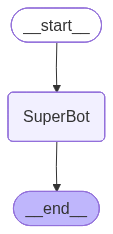

In [11]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [12]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='f2a1bf4d-c58c-4dde-88aa-a2e8515f8ee5'),
  AIMessage(content="Nice to meet you, Krish. It's great to hear that you like cricket. Cricket is a fantastic sport, full of excitement, strategy, and thrilling moments. Which team or player is your favorite in international cricket? Are you from India, or do you have another favorite team?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 45, 'total_tokens': 103, 'completion_time': 0.115600093, 'completion_tokens_details': None, 'prompt_time': 0.002301526, 'prompt_tokens_details': None, 'queue_time': 0.067320601, 'total_time': 0.117901619}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e09ee421cf', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1fd7-8b6c-7212-b450-6ee9f3f121a4-0', tool_c

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

#### Streaming The Responses With Stream Method

In [27]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Bilal And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Bilal. I've been chatting with someone named Krish earlier, but I'm happy to start a new conversation with you. It seems like we have a lot in common, though - we both like cricket!\n\nSo, Bilal, what do you like about cricket? Are you a fan of a particular team or player? Do you play cricket yourself, or do you enjoy watching it on TV?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 86, 'prompt_tokens': 1169, 'total_tokens': 1255, 'completion_time': 0.155171637, 'completion_tokens_details': None, 'prompt_time': 0.100803423, 'prompt_tokens_details': None, 'queue_time': 0.075732549, 'total_time': 0.25597506}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1fde-a3c1-7f52-ad0c-b9fb3ffc8f97-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inpu

In [28]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a66eb266-0ce9-460f-a1da-4a42bab3ff55'), AIMessage(content="Nice to meet you, Krish! Cricket is an amazing sport, and I'm happy to chat with you about it. Are you a fan of a particular team or player? Do you play cricket yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.063870025, 'completion_tokens_details': None, 'prompt_time': 0.002151753, 'prompt_tokens_details': None, 'queue_time': 0.018037026, 'total_time': 0.066021778}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1fd8-7ef8-7c81-8a44-43628d06d588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_to

In [29]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='It seems like we\'re back to square one again, Bilal. I understand that you like football, but I\'d love to have a more in-depth conversation about it.\n\nLet\'s try to move beyond the phrase "I also like football." Can you tell me something specific about football that you enjoy? For example, do you like a particular team, player, or league? Or is there something about the sport itself that you appreciate?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 89, 'prompt_tokens': 1381, 'total_tokens': 1470, 'completion_time': 0.112315416, 'completion_tokens_details': None, 'prompt_time': 0.077186475, 'prompt_tokens_details': None, 'queue_time': 0.01902387, 'total_time': 0.189501891}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_6a1eabf260', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1fde-c5cb-73e2-a2c5-1bf98342aaf0-0', tool_

In [30]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a66eb266-0ce9-460f-a1da-4a42bab3ff55'), AIMessage(content="Nice to meet you, Krish! Cricket is an amazing sport, and I'm happy to chat with you about it. Are you a fan of a particular team or player? Do you play cricket yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.063870025, 'completion_tokens_details': None, 'prompt_time': 0.002151753, 'prompt_tokens_details': None, 'queue_time': 0.018037026, 'total_time': 0.066021778}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_03e8423237', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1fd8-7ef8-7c81-8a44-43628d06d588-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_to

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [32]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Bilal and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Bilal and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e1fe0-0f5f-79e0-89d3-55a984f09bae', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='a66eb266-0ce9-460f-a1da-4a42bab3ff55'), AIMessage(content="Nice to meet you, Krish! Cricket is an amazing sport, and I'm happy to chat with you about it. Are you a fan of a particular team or player? Do you play cricket yourself or just enjoy watching it?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 45, 'total_tokens': 92, 'completion_time': 0.063870025, 'completion_tokens_details': None, 'prompt_time': 0.002151753, 'prompt_tokens_details': None, 'queue_time': 0.018037026, 'total_time': 0.06